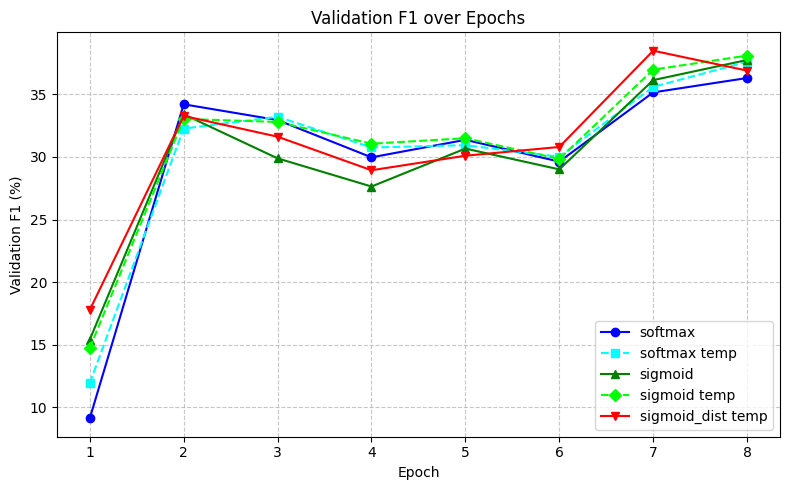

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data as given: each entry is a tuple of (mean, std)
# Rows correspond to: softmax, softmax temp, sigmoid, sigmoid temp, sigmoid_dist temp
# Each row has 8 epochs (mean ± std)
data_str = {
    'softmax': "9.12 ± 10.39 34.21 ± 8.08 32.95 ± 8.55 29.97 ± 6.68 31.37 ± 15.85 29.63 ± 8.16 35.16 ± 11.09 36.31 ± 9.05",
    'softmax temp': "11.93 ± 10.23 32.27 ± 10.06 33.21 ± 9.92 30.76 ± 7.68 30.94 ± 14.25 30.02 ± 7.28 35.6 ± 11.97 37.61 ± 6.54",
    'sigmoid': "15.41 ± 7.85 33.41 ± 10.52 29.89 ± 17.35 27.64 ± 8.24 30.67 ± 18.25 29.01 ± 8.51 36.14 ± 11.54 37.75 ± 7.28",
    'sigmoid temp': "14.73 ± 10.52 33.04 ± 10 32.8 ± 10.83 31.06 ± 7.06 31.5 ± 13.11 29.84 ± 8.43 36.98 ± 11.27 38.1 ± 5.81",
    'sigmoid_dist temp': "17.78 ± 12.3 33.28 ± 9.9 31.62 ± 9.61 28.94 ± 7.98 30.1 ± 13.84 30.8 ± 10.79 38.49 ± 12.78 36.9 ± 7.66"
}

# Parse each row into lists of means and stds
def parse_row(row_str):
    parts = row_str.split()
    means = []
    stds = []
    # each 'mean ± std' is two elements (mean, '±', std) – but the ± is a separate token
    # Actually the string has spaces around ±, e.g., "9.12 ± 10.39"
    # We'll split and then iterate in steps of 3
    tokens = parts
    for i in range(0, len(tokens), 3):
        mean = float(tokens[i])
        std = float(tokens[i+2])
        means.append(mean)
        stds.append(std)
    return np.array(means), np.array(stds)

epochs = np.arange(1, 9)

# Plot settings
plt.figure(figsize=(8, 5))
colors = ['blue', 'cyan', 'green', 'lime', 'red']
linestyles = ['-', '--', '-', '--', '-']
markers = ['o', 's', '^', 'D', 'v']

for (name, row_str), color, ls, marker in zip(data_str.items(), colors, linestyles, markers):
    means, stds = parse_row(row_str)
    # Compute cumulative best (running max of means)
    # cum_best = np.maximum.accumulate(means)
    plt.plot(epochs, means, color=color, linestyle=ls, marker=marker, label=name)


plt.xlabel('Epoch')
plt.ylabel('Validation F1 (%)')
plt.title('Validation F1 over Epochs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('validation_f1.png', dpi=300)
plt.show()